#### To perform Simple Linear Regression on height-weight dataset using Regularization techniques


#### Step 1: Import  all the necessary  libraries

In [2009]:
import  numpy             as  np
import  pandas            as  pd
import  matplotlib.pyplot as  plt
import  seaborn           as  sns

from    sklearn.model_selection  import  train_test_split, GridSearchCV, KFold
from    sklearn.preprocessing    import  StandardScaler
from    sklearn.linear_model     import  LinearRegression, Ridge, Lasso, ElasticNet
from    sklearn.metrics          import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2: Load the Dataset

In [2010]:
df = pd.read_csv("height-weight.csv")

In [2011]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


#### OBSERVATIONS:

1.  The above dataset explains about the Weight vs Height for diferent people in the dataset.

#### Step 3: Perform the Data Exploration

In [2012]:
#### get the top five rows of the dataset

df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [2013]:
#### get the bottom five rows of the dataset

df.tail()

,Weight,Height
18,76,150
19,87,167
20,45,129
21,56,140
22,72,160


In [2014]:
#### get the length of the dataset


print("Length of the dataset is:", len(df))

Length of the dataset is: 23


In [2015]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (23, 2)


In [2016]:
#### get the columns used in the dataset

df.columns

Index(['Weight', 'Height'], dtype='object')

In [2017]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 496.0 bytes


#### OBSERVATIONS:

1.  The columns 'Weight' and 'Height' are integer in number.

In [2018]:
#### get the descriptive summary statistics about the columns in the dataset

df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


#### OBSERVATIONS:

1.  The above summary explains about the statistical summary for each numerical column in the dataset.

In [2019]:
#### get the correlation between the numerical columns in the dataset

df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


<Axes: >

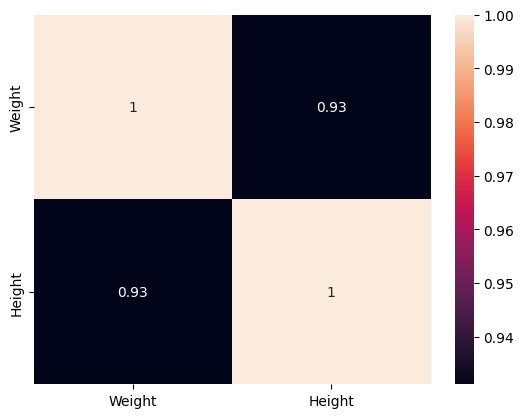

In [2020]:
#### get the graphical representation for the correlation between the numerical columns in the dataset


sns.heatmap(df.corr(),annot=True)

#### OBSERVATIONS:

1.  There exists a very high correlation between Height vs Weight in the dataset.

#### Step 4: Perform the Data Cleaning

In [2021]:
#### Check for the NULL Values in the dataset

df.isnull().sum()

Weight    0
Height    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [2022]:
#### Check for the duplicate records in the dataset

df[df.duplicated()]

,Weight,Height
11,95,182


#### OBSERVATIONS:

1.  There is one duplicate record in the dataset.

In [2023]:
#### Remove the duplicate records from the dataset

df = df.drop_duplicates()

In [2024]:
#### Again Check for the duplicate records in the dataset

df[df.duplicated()]

,Weight,Height


#### OBSERVATIONS:

1.  There are no duplicate record in the dataset after removing the duplicate record.

#### Step 5: Divide the dataset into independent and dependent features

In [2025]:
#### independent features

X = df.drop(columns='Height', axis=1)

print(X)

    Weight
0       45
1       58
2       48
3       60
4       70
5       78
6       80
7       90
8       95
9       78
10      82
12     105
13     100
14      85
15      78
16      50
17      65
18      76
19      87
20      45
21      56
22      72


In [2026]:
#### dependent features

Y = df[['Height']]

print(Y)

    Height
0      120
1      135
2      123
3      145
4      160
5      162
6      163
7      175
8      182
9      170
10     176
12     175
13     183
14     170
15     177
16     140
17     159
18     150
19     167
20     129
21     140
22     160


#### Step 6: Divide the independent and dependent features into training and testing data

In [2027]:
from  sklearn.model_selection import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [2028]:
X_train

,Weight
5,78
21,56
12,105
3,60
4,70
18,76
13,100
19,87
17,65
2,48


In [2029]:
X_test

,Weight
0,45
14,85
8,95
1,58
16,50


In [2030]:
print("Shape of the input training data is:", X_train.shape)

print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (17, 1)
Shape of the input testing  data is: (5, 1)


In [2031]:
Y_train

,Height
5,162
21,140
12,175
3,145
4,160
18,150
13,183
19,167
17,159
2,123


In [2032]:
Y_test

,Height
0,120
14,170
8,182
1,135
16,140


In [2033]:
print("Shape of the output training data is:", Y_train.shape)

print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (17, 1)
Shape of the output testing  data is: (5, 1)


#### Step 7: Perform Feature Scaling on the inputs

In [2034]:
from  sklearn.preprocessing  import  StandardScaler

##### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

In [2035]:
X_train_scaled

array([[ 0.20608301],
       [-1.17025708],
       [ 1.89522766],
       [-0.92001342],
       [-0.2944043 ],
       [ 0.08096118],
       [ 1.58242309],
       [ 0.76913122],
       [-0.60720886],
       [-1.67074438],
       [ 0.20608301],
       [-0.16928247],
       [ 0.95681396],
       [ 0.45632666],
       [ 0.20608301],
       [-1.85842712],
       [ 0.33120483]])

In [2036]:
X_test_scaled

array([[-1.85842712],
       [ 0.6440094 ],
       [ 1.26961853],
       [-1.04513525],
       [-1.54562255]])

#### OBSERVATIONS:

1.  Here all the inputs have been transformed in the same scale range.

#### Step 8: Train the Linear Regression Model with Regularization techniques

In [2037]:
from  sklearn.linear_model  import  LinearRegression, Ridge, Lasso, ElasticNet


#### create an object for LinearRegression, Ridge, Lasso, ElasticNet

lin        = LinearRegression()
ridge      = Ridge(alpha=0.1)
lasso      = Lasso(alpha=1.0)
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [2038]:
#### Train the model with the objects of linear regression as well as regularization techniques


lin.fit(X_train_scaled, Y_train)

LinearRegression()

In [2039]:
ridge.fit(X_train_scaled, Y_train)

Ridge(alpha=0.1)

In [2040]:
lasso.fit(X_train_scaled, Y_train)

Lasso()

In [2041]:
elasticnet.fit(X_train_scaled, Y_train)

ElasticNet(alpha=0.1)

#### OBSERVATIONS:

1.  The models for LinearRegression, Ridge, Lasso, ElasticNet has been trained with the help of the training data respectively.

#### Step 9: Predict the model

In [2042]:
Y_pred_lin = lin.predict(X_test_scaled)

In [2043]:
Y_pred_lin

array([[131.74187432],
       [169.31717226],
       [178.71099675],
       [143.95384615],
       [136.43878657]])

In [2044]:
Y_pred_ridge = ridge.predict(X_test_scaled)

In [2045]:
Y_pred_ridge

array([[131.90506254],
       [169.26062189],
       [178.59951173],
       [144.04561933],
       [136.57450746]])

In [2046]:
Y_pred_lasso = lasso.predict(X_test_scaled)

In [2047]:
Y_pred_lasso

array([133.60030144, 168.67316287, 177.44137822, 144.9989814 ,
       137.98440912])

In [2048]:
Y_pred_elasticnet = elasticnet.predict(X_test_scaled)

In [2049]:
Y_pred_elasticnet

array([133.15918916, 168.82602356, 177.74273216, 144.75091034,
       137.61754346])

#### Step 10: Calculate the slope and intercept of the model

#### (a.)  Linear Regression

In [2050]:
print("Slope of the model is:", lin.coef_)
print("Intercept of the model is:", lin.intercept_[0])

Slope of the model is: [[15.01548499]]
Intercept of the model is: 159.64705882352942


#### (b.)  Ridge Regression

In [2051]:
print("Slope of the model is:", ridge.coef_)
print("Intercept of the model is:", ridge.intercept_[0])

Slope of the model is: [[14.92767514]]
Intercept of the model is: 159.64705882352942


#### (c.)  Lasso Regression

In [2052]:
print("Slope of the model is:", lasso.coef_)
print("Intercept of the model is:", lasso.intercept_[0])

Slope of the model is: [14.01548499]
Intercept of the model is: 159.64705882352942


#### (d.)  Elastic Net Regression

In [2053]:
print("Slope of the model is:", elasticnet.coef_)
print("Intercept of the model is:", elasticnet.intercept_[0])

Slope of the model is: [14.25284285]
Intercept of the model is: 159.64705882352942


#### Step 11: Evaluate the Regression Metrics


##### (a.)  Linear Regression

In [2054]:
from  sklearn.metrics  import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

maelin = mean_absolute_error(Y_test, Y_pred_lin)
print("Mean Absolute Error of the model is:", maelin)

Mean Absolute Error of the model is: 5.645752979414942


In [2055]:
mselin = mean_squared_error(Y_test, Y_pred_lin)
print("Mean Squared Error of the model is:", mselin)

Mean Squared Error of the model is: 48.401802156635064


In [2056]:
rmselin = root_mean_squared_error(Y_test, Y_pred_lin)
print("Root Mean Squared Error of the model is:", rmselin)

Root Mean Squared Error of the model is: 6.957140372066318


In [2057]:
r2lin = r2_score(Y_test, Y_pred_lin)
print("R2 Score of the linear regressionmodel is:", r2lin)

R2 Score of the linear regressionmodel is: 0.9085792494774949


#### OBSERVATIONS:

1. The r2 score of the model is 0.9085 which is very high. So the model is working fine.

##### (b.)  Ridge Regression

In [2058]:
maeridge = mean_absolute_error(Y_test, Y_pred_ridge)
print("Mean Absolute Error of the model is:", maeridge)

Mean Absolute Error of the model is: 5.7032081563499215


In [2059]:
mseridge = mean_squared_error(Y_test, Y_pred_ridge)
print("Mean Squared Error of the model is:", mseridge)

Mean Squared Error of the model is: 49.479548523902906


In [2060]:
rmseridge = root_mean_squared_error(Y_test, Y_pred_ridge)
print("Root Mean Squared Error of the model is:", rmseridge)

Root Mean Squared Error of the model is: 7.034170066461495


In [2061]:
r2ridge = r2_score(Y_test, Y_pred_ridge)
print("R2 Score of the Ridge regressionmodel is:", r2ridge)

R2 Score of the Ridge regressionmodel is: 0.9065436149064995


#### OBSERVATIONS:

1. The r2 score of the model is 0.9065 which is very high. So the model is working fine.

#### (c.)  Lasso Regression

In [2062]:
maelasso = mean_absolute_error(Y_test, Y_pred_lasso)
print("Mean Absolute Error of the model is:", maelasso)

Mean Absolute Error of the model is: 6.300066527227893


In [2063]:
mselasso = mean_squared_error(Y_test, Y_pred_lasso)
print("Mean Squared Error of the model is:", mselasso)

Mean Squared Error of the model is: 62.31039285991708


In [2064]:
rmselasso = root_mean_squared_error(Y_test, Y_pred_lasso)
print("Root Mean Squared Error of the model is:", rmselasso)

Root Mean Squared Error of the model is: 7.893693233203142


In [2065]:
r2lasso = r2_score(Y_test, Y_pred_lasso)
print("R2 Score of the Lasso regressionmodel is:", r2lasso)

R2 Score of the Lasso regressionmodel is: 0.8823088681249678


#### OBSERVATIONS:

1. The r2 score of the model is 0.8823 which is very high. So the model is working fine.

2. But the R2 Score is lower than Linear and then Ridge Regression.

#### (d.)  ElasticNet Regression

In [2066]:
maeelasticnet = mean_absolute_error(Y_test, Y_pred_elasticnet)
print("Mean Absolute Error of the model is:", maeelasticnet)

Mean Absolute Error of the model is: 6.144760065305053


In [2067]:
mseelasticnet = mean_squared_error(Y_test, Y_pred_elasticnet)
print("Mean Squared Error of the model is:", mseelasticnet)

Mean Squared Error of the model is: 58.684632240283314


In [2068]:
rmseelasticnet = root_mean_squared_error(Y_test, Y_pred_elasticnet)
print("Root Mean Squared Error of the model is:", rmseelasticnet)

Root Mean Squared Error of the model is: 7.660589549132841


In [2069]:
r2elasticnet = r2_score(Y_test, Y_pred_elasticnet)
print("R2 Score of the ElasticNet regressionmodel is:", r2elasticnet)

R2 Score of the ElasticNet regressionmodel is: 0.8891571618308338


#### OBSERVATIONS:

1. The r2 score of the model is 0.8891 which is very high. So the model is working fine.

2. But the R2 Score is lower than Linear and then Ridge Regression but higher than Lasso regression

3. Lasso <  ElasticNet <  Ridge < Linear  ------------>  ascending order of R2 Score.

#### Step 12: Plot Training data plot best fit line


##### (a.)  Linear Regression

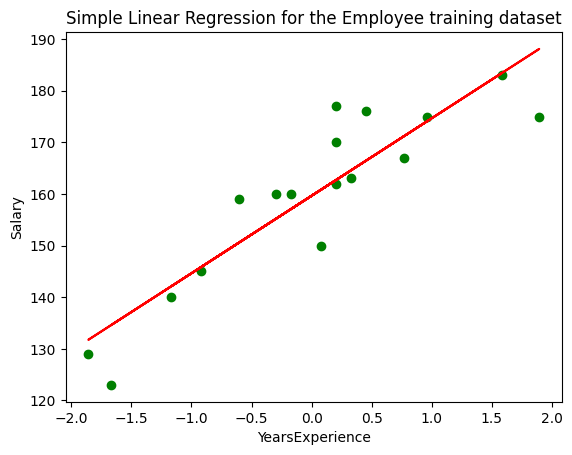

In [2070]:
#### plot the actual training data points
plt.scatter(X_train_scaled, Y_train, color = 'green', label = 'Actual training data points')

#### plot the best line of fit
plt.plot(X_train_scaled, lin.predict(X_train_scaled), color = 'red', label = 'Best line of fit for the training data')

#### mention the title of the graph
plt.title("Simple Linear Regression for the Employee training dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### (b.)  Ridge Regression

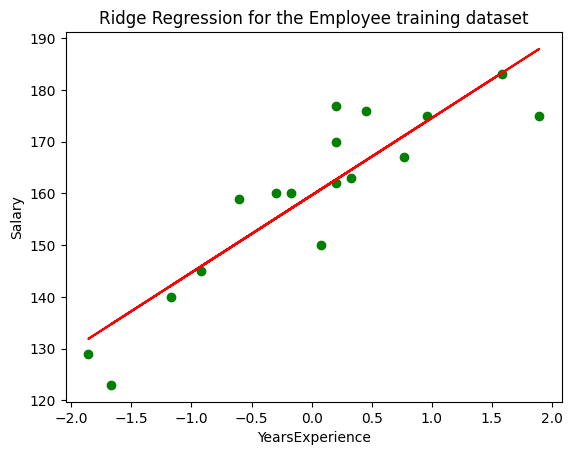

In [2071]:
#### plot the actual training data points
plt.scatter(X_train_scaled, Y_train, color = 'green', label = 'Actual training data points')

#### plot the best line of fit
plt.plot(X_train_scaled, ridge.predict(X_train_scaled), color = 'red', label = 'Best line of fit for the training data')

#### mention the title of the graph
plt.title("Ridge Regression for the Employee training dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### (c.)  Lasso Regression

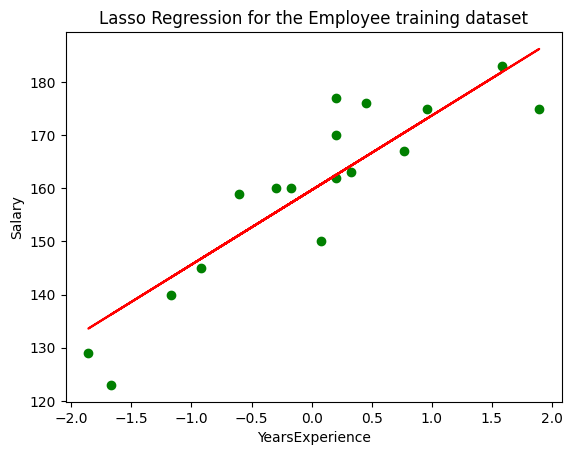

In [2072]:
#### plot the actual training data points
plt.scatter(X_train_scaled, Y_train, color = 'green', label = 'Actual training data points')

#### plot the best line of fit
plt.plot(X_train_scaled, lasso.predict(X_train_scaled), color = 'red', label = 'Best line of fit for the training data')

#### mention the title of the graph
plt.title("Lasso Regression for the Employee training dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### (d.)  Elastic Net Regression

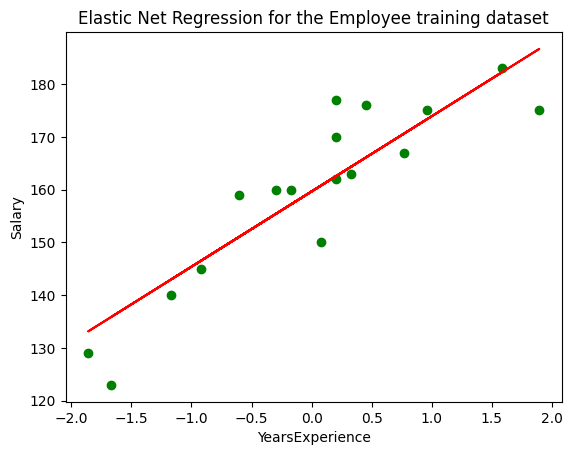

In [2073]:
#### plot the actual training data points
plt.scatter(X_train_scaled, Y_train, color = 'green', label = 'Actual training data points')

#### plot the best line of fit
plt.plot(X_train_scaled, elasticnet.predict(X_train_scaled), color = 'red', label = 'Best line of fit for the training data')

#### mention the title of the graph
plt.title("Elastic Net Regression for the Employee training dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### OBSERVATIONS:

1.  The best fit of line is accurately  passing through the training data points using Linear Regression and various Regularization techniques.

#### Step 13: Plot Testing data plot best fit line


##### (a.)  Linear Regression

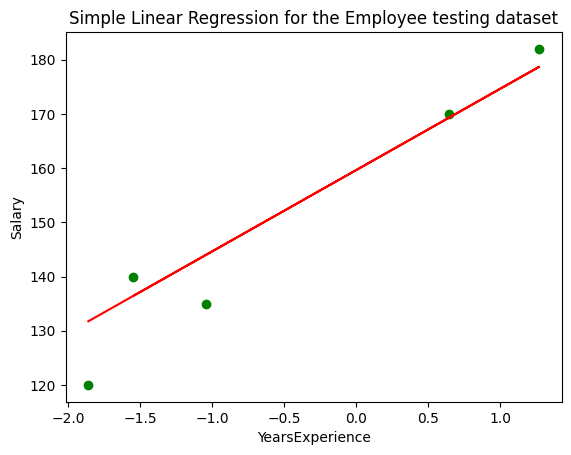

In [2074]:
#### plot the actual testing data points
plt.scatter(X_test_scaled, Y_test, color = 'green', label = 'Actual testing data points')

#### plot the best line of fit
plt.plot(X_test_scaled, lin.predict(X_test_scaled), color = 'red', label = 'Best line of fit for the testing data')

#### mention the title of the graph
plt.title("Simple Linear Regression for the Employee testing dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### (b.)  Ridge Regression

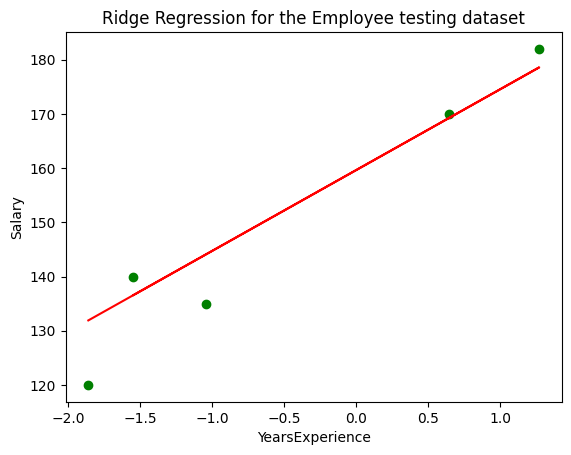

In [2075]:
#### plot the actual testing data points
plt.scatter(X_test_scaled, Y_test, color = 'green', label = 'Actual testing data points')

#### plot the best line of fit
plt.plot(X_test_scaled, ridge.predict(X_test_scaled), color = 'red', label = 'Best line of fit for the testing data')

#### mention the title of the graph
plt.title("Ridge Regression for the Employee testing dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### (c.)  Lasso Regression

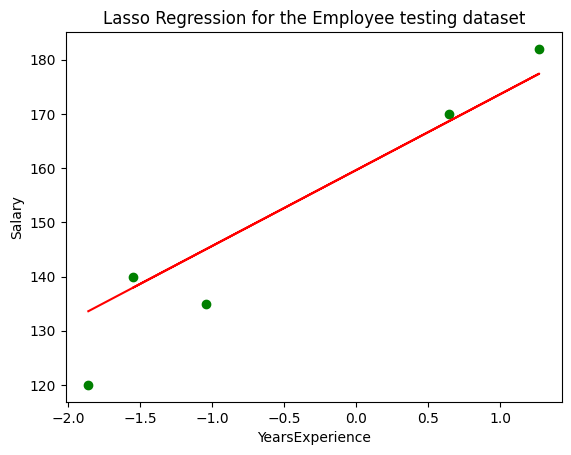

In [2076]:
#### plot the actual testing data points
plt.scatter(X_test_scaled, Y_test, color = 'green', label = 'Actual testing data points')

#### plot the best line of fit
plt.plot(X_test_scaled, lasso.predict(X_test_scaled), color = 'red', label = 'Best line of fit for the testing data')

#### mention the title of the graph
plt.title("Lasso Regression for the Employee testing dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### (d.)  ElasticNet Regression

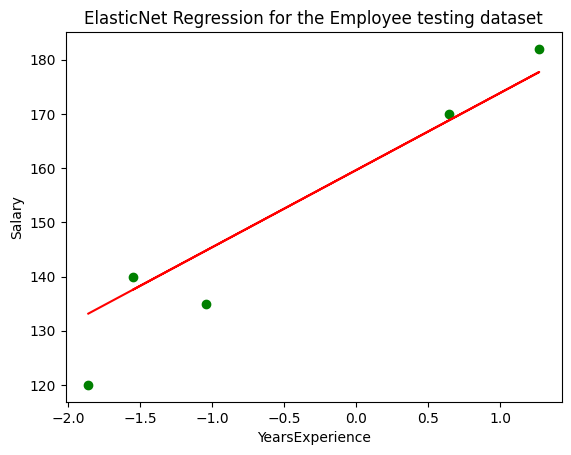

In [2077]:
#### plot the actual testing data points
plt.scatter(X_test_scaled, Y_test, color = 'green', label = 'Actual testing data points')

#### plot the best line of fit
plt.plot(X_test_scaled, elasticnet.predict(X_test_scaled), color = 'red', label = 'Best line of fit for the testing data')

#### mention the title of the graph
plt.title("ElasticNet Regression for the Employee testing dataset")


#### mention the x-axis of the graph
plt.xlabel("YearsExperience")

#### mention the y-axis of the graph
plt.ylabel("Salary")

#### display the graph
plt.show()

##### OBSERVATIONS:

1.  The best fit of line is accurately  passing through the testing data points using Linear Regression and various Regularization techniques.